In [6]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from pallm.framework import attribute_names

df = pd.read_csv('../analysis/all-questions-two-runs.csv', index_col=0)
df = df[df.run_a == df.run_b]
df

,lga,state,declared,question,run_a,run_b,answer_a,answer_b,quote_a,quote_b,attribute,qscore
0,Adelaide,SA,False,1,True,True,"The policy under review, the Corporate Carbon ...","The policy under review, the Corporate Carbon ...",The AHC Strategic Plan (2016) states that “we ...,The AHC Strategic Plan (2016) states that “we ...,1,1
1,Adelaide,SA,False,2,True,True,The documents do explicitly explain the need f...,The documents clearly articulate the need for ...,This plan sets out Council’s goals and targets...,This plan sets out Council’s goals and targets...,1,1
2,Adelaide,SA,False,3,False,False,The documents do not explicitly call for rapid...,The documents do not explicitly call for rapid...,NaN,NaN,2,0
3,Adelaide,SA,False,4,True,True,The documents do provide specific timeframes f...,The documents do provide specific timeframes f...,Figure 8 below shows that 100% renewable energ...,Figure 8 below shows that 100% renewable energ...,2,1
4,Adelaide,SA,False,5,False,False,The documents do not explicitly state that a c...,The documents do not explicitly state that a c...,NaN,NaN,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2935,Yorke,SA,False,16,True,True,The documents indeed show an explicit intent t...,The documents indeed show an explicit intent t...,Develop state wide policies for biodiversity m...,Develop state wide policies for biodiversity m...,9,1
2936,Yorke,SA,False,17,True,True,The document does explicitly encourage buildin...,The document does explicitly encourage buildin...,Regular review and update of regional climate ...,Establish a network of regional climate change...,9,1
2937,Yorke,SA,False,18,True,True,The documents indeed refer to specific regiona...,The documents indeed refer to specific regiona...,NaN,NaN,9,1
2938,Yorke,SA,False,19,True,True,The documents do explicitly discuss the impact...,The documents do discuss the impact of climate...,NaN,NaN,10,1


In [7]:
attrdf = pd.DataFrame(attribute_names, columns=['name'])
attrdf['num'] = range(1,11)
#attrdf['mean'] = [0,0,0,0,0,0,0,0,0,0,]
attrdf['mean'] = 0.0
attrdf['declared_mean'] = 0.0
attrdf['nondeclared_mean'] = 0.0

def is_declared(row):
    lganame = row.lga
    return lga.loc[lganame].is_declared
    
#df['is_declared'] = df.apply(is_declared, axis=1)
df.declared.value_counts()
attrdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              10 non-null     object 
 1   num               10 non-null     int64  
 2   mean              10 non-null     float64
 3   declared_mean     10 non-null     float64
 4   nondeclared_mean  10 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 528.0+ bytes


In [8]:
# questions with mixed findings - will be excluded from analysis
df[df.qscore == 0.5].question.value_counts()

Series([], Name: count, dtype: int64)

In [9]:
attrdf = attrdf.sort_values('num',ascending=True)
for i, name in enumerate(attribute_names):
    adf = df[df.attribute==(i+1)]
    #attrdf['num'].iloc[i] = i
    attrdf.loc[i,'num'] = i
    #attrdf['mean'].iloc[i] = adf.qscore.mean()
    attrdf.loc[i,'mean'] = adf.qscore.mean()
    #attrdf['declared_mean'].iloc[i] = adf[adf.declared].qscore.mean()
    attrdf.loc[i,'declared_mean'] = adf[adf.declared].qscore.mean()
    #attrdf['nondeclared_mean'].iloc[i] = adf[~adf.declared].qscore.mean()
    attrdf.loc[i,'nondeclared_mean'] = adf[~adf.declared].qscore.mean()
    #print(adf.info())
    #print(adf.qscore.mean())
    #print(len(adf.question.unique()))
    #print(adf.qscore.sum()/len(adf.qscore))

attrs = attrdf.name.values
attrs[3] = 'Institutional resource\nmobilisation'
attrs[6] = 'Adapting to a\nchanging climate'
attrs[7] = 'Planning for\ninformed action'
attrs[8] = 'Coordination,\npartnerships\nand advocacy'

attrdf = attrdf.sort_values('num',ascending=False)

attrdf

,name,num,mean,declared_mean,nondeclared_mean
9,Equity and social justice,9,0.158076,0.226087,0.113636
8,"Coordination,\npartnerships\nand advocacy",8,0.609302,0.707602,0.544402
7,Planning for\ninformed action,7,0.500000,0.576577,0.450292
6,Adapting to a\nchanging climate,6,0.863946,0.844828,0.876404
5,Restoring a safe climate,5,0.772414,0.965517,0.643678
4,Social mobilisation,4,0.901408,0.947368,0.870588
3,Institutional resource\nmobilisation,3,0.569395,0.607143,0.544379
2,Prioritisation of action,2,0.113402,0.184211,0.067797
1,Urgency of action,1,0.515464,0.686957,0.403409
0,Purpose of action,0,0.903780,0.956897,0.868571


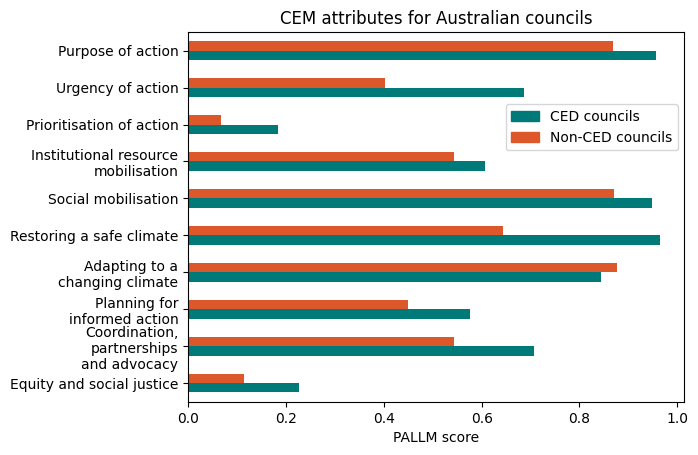

In [10]:
color_names = ['#7da1c4','#dc582a','#007a78']
color_names = ['#007a78','#dc582a']

ax = attrdf.plot.barh(y=['declared_mean','nondeclared_mean'], x='name', color=color_names, title='CEM attributes for Australian councils')#, figsize=(10,4)
#plt.savefig('figures/attr-results.png')
ax.set_ylabel("")
ax.set_xlabel("PALLM score")
handles = [mpatches.Patch(color=color_names[0], label='CED councils'), mpatches.Patch(color=color_names[1], label='Non-CED councils')]
ax.legend(handles=handles, loc=(0.64,0.68))# , bbox_to_anchor=(1,1))
#attrdf[['mean','declared_mean','nondeclared_mean']]
plt.savefig('figures/lga-attribute-results-au.png', dpi=300, bbox_inches = "tight")

In [11]:
from common import get_qscore_attr_score

def get_lga_scores(df, lga_list):                                               
    lga_scores = []                                                             
    for lga in lga_list:                                                        
        ldf = df[df.lga==lga]                                                   
        scores = []                                                             
        for a in range(1,11):                                                   
            adf = ldf[ldf.attribute==a]
            attr_score = get_qscore_attr_score(adf)
            #print(f"score for attr {a}: {attr_score}")                         
            scores.append(attr_score)                                           
        overall = round(sum(scores)/10*100,2)                                   
            #print(f"Overall score for {lga}: {overall}")    
        lga_scores.append([lga, overall, ldf.declared.iloc[0]])
    return lga_scores     

In [12]:
lga_scores = get_lga_scores(df, df.lga.unique())
#for pair in lga_scores:
#    lganame = pair[0]
#    pair.extend([lga.loc[lganame].is_declared, lga.loc[lganame].asgc_status, lga.loc[lganame].is_metro])
#lga_scores

In [13]:
score_df = pd.DataFrame(lga_scores, columns=['lga','score','declared'])
score_df.index=score_df.lga
score_df=score_df.drop('lga', axis=1)
score_df

,score,declared
lga,,
Adelaide,58.33,False
Alexandrina,70.00,True
Alpine,57.50,False
Armadale,40.00,False
Armidale,71.67,True
...,...,...
Wollongong,32.50,True
Wyndham,64.17,False
Yarra,83.33,True


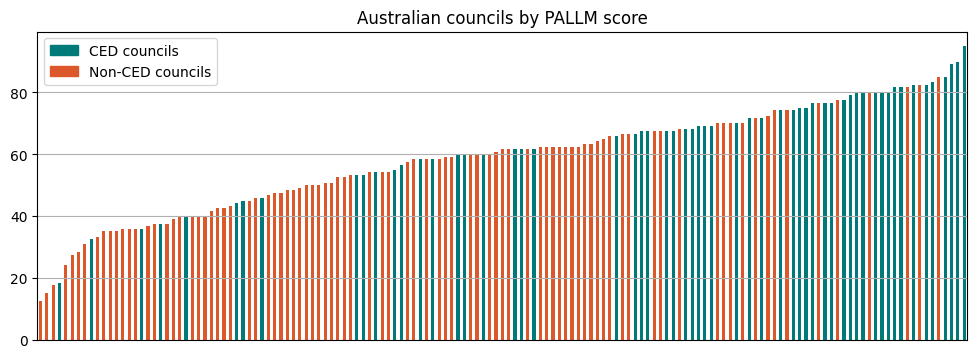

In [14]:
import numpy as np

#color_names = ["seagreen", "lightblue"]
color_names = ['#007a78','#7da1c4','#dc582a']
color_names = ['#007a78','#dc582a']
colors = []
labels = {"declared": color_names[0], "non-declared": color_names[1]}
showlabels = {"declared": "CED councils", "non-declared": "Non-CED councils"}

decl = 0
for val in score_df.sort_values('score').declared:
    if val:
        colors.append(labels['declared'])
        decl += 1
    else:
        colors.append(labels['non-declared'])
        
ax = score_df.sort_values('score').plot.bar(y='score',figsize=(12,4), color=colors, title='Australian councils by PALLM score')
ax.set_xticks([],[])
handles = [mpatches.Patch(color=v, label=showlabels[k]) for k, v in labels.items()]
ax.legend(handles=handles)
ax.grid(visible=True, axis='y')
ax.set_xlabel("")
#plt.savefig('figures/pallm-score-by-lga-no-name.png', dpi=300, bbox_inches = "tight")
plt.savefig('figures/pallm-score-by-lga-au.png', dpi=300, bbox_inches = "tight")

In [15]:
score_df.score.describe()

count    147.000000
mean      58.713401
std       16.900025
min       12.500000
25%       47.085000
50%       61.670000
75%       70.000000
max       95.000000
Name: score, dtype: float64

In [17]:
# Stats for all declared LGAs
score_df[score_df.declared].describe()

,score
count,58.000000
mean,66.710345
std,15.527863
min,18.330000
25%,58.747500
50%,68.750000
75%,78.752500
max,95.000000


In [18]:
# Mean etc for non-declared LGAs
score_df[~score_df.declared].describe()

,score
count,89.000000
mean,53.501910
std,15.749921
min,12.500000
25%,41.670000
50%,54.170000
75%,63.330000
max,85.000000


In [27]:
attrsum = attrdf[['num','name','mean','declared_mean','nondeclared_mean']].copy()
attrsum['overall_mean'] = attrsum['mean']
attrsum = attrsum.drop('mean', axis=1)
attrsum['mean_diff'] = attrsum['declared_mean'] - attrsum['nondeclared_mean']
attrsum['mean_pct'] = 1 - (attrsum['nondeclared_mean'] / attrsum['declared_mean'])
attrsum.overall_mean = attrsum.overall_mean.apply(lambda x: round(x * 100,1))
attrsum.declared_mean = attrsum.declared_mean.apply(lambda x: round(x * 100,1))
attrsum.nondeclared_mean = attrsum.nondeclared_mean.apply(lambda x: round(x * 100,1))
attrsum.sort_values('num')

,num,name,declared_mean,nondeclared_mean,overall_mean,mean_diff,mean_pct
0,0,Purpose of action,95.7,86.9,90.4,0.088325,0.092304
1,1,Urgency of action,68.7,40.3,51.5,0.283547,0.412759
2,2,Prioritisation of action,18.4,6.8,11.3,0.116414,0.631961
3,3,Institutional resource\nmobilisation,60.7,54.4,56.9,0.062764,0.103376
4,4,Social mobilisation,94.7,87.1,90.1,0.076780,0.081046
5,5,Restoring a safe climate,96.6,64.4,77.2,0.321839,0.333333
6,6,Adapting to a\nchanging climate,84.5,87.6,86.4,-0.031577,-0.037377
7,7,Planning for\ninformed action,57.7,45.0,50.0,0.126284,0.219024
8,8,"Coordination,\npartnerships\nand advocacy",70.8,54.4,60.9,0.163201,0.230639
9,9,Equity and social justice,22.6,11.4,15.8,0.112451,0.497378


In [20]:
# Top 5 attributes by relative difference
attrsum.sort_values('mean_pct').tail(n=5)

,num,name,mean,declared_mean,nondeclared_mean,allmean,mean_diff,mean_pct
8,8,"Coordination,\npartnerships\nand advocacy",0.609302,70.8,54.4,60.9,0.163201,0.230639
5,5,Restoring a safe climate,0.772414,96.6,64.4,77.2,0.321839,0.333333
1,1,Urgency of action,0.515464,68.7,40.3,51.5,0.283547,0.412759
9,9,Equity and social justice,0.158076,22.6,11.4,15.8,0.112451,0.497378
2,2,Prioritisation of action,0.113402,18.4,6.8,11.3,0.116414,0.631961


In [21]:
# Top 5 attributes by absolute difference
attrsum.sort_values('mean_diff').tail(n=5)

,num,name,mean,declared_mean,nondeclared_mean,allmean,mean_diff,mean_pct
2,2,Prioritisation of action,0.113402,18.4,6.8,11.3,0.116414,0.631961
7,7,Planning for\ninformed action,0.500000,57.7,45.0,50.0,0.126284,0.219024
8,8,"Coordination,\npartnerships\nand advocacy",0.609302,70.8,54.4,60.9,0.163201,0.230639
1,1,Urgency of action,0.515464,68.7,40.3,51.5,0.283547,0.412759
5,5,Restoring a safe climate,0.772414,96.6,64.4,77.2,0.321839,0.333333
